# Jigsaw Puzzle Solver - System Showcase

This notebook demonstrates the complete jigsaw puzzle solving system with:

- **Success Cases**: Image 5 (2x2), Image 40 (4x4), Image 88 (8x8)
- **Failure Case**: Image 29 (4x4) with analysis
- **Intermediate Results**: Edge matching, candidate matches, similarity scores
- **Visualization**: Overlayed matched edges, connecting lines between candidate matches

## Setup Note

First, we'll preprocess the puzzle images to generate the required piece data (original, prep, upscaled, binary, edges, contours).


In [1]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Tuple

# Add project root to path
sys.path.insert(0, os.path.abspath("."))

from utils.piece_loader import PieceLoader
from utils.similarity import SimilarityCalculator
from utils.image_utils import merge_pieces, load_image, split_image
from utils.preprocessing import preprocess
from utils.upscale import upscale_lanczos_sharp
from solvers.solver import solve

## Preprocessing Functions

First, let's create functions to preprocess puzzle images if needed.


In [2]:
def preprocess_puzzle(
    image_path: str, output_dir: Path, puzzle_id: int, grid_size: int
):
    """
    Preprocess a single puzzle image and generate all required outputs.
    """
    # Create output directories
    dirs = {
        "original": output_dir / "original",
        "prep": output_dir / "prep",
        "upscaled": output_dir / "upscaled",
        "binary": output_dir / "binary",
        "edges": output_dir / "edges",
        "contours": output_dir / "contours",
    }
    for d in dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    # Load and split image
    image = load_image(image_path)
    piece_size = image.shape[0] // grid_size
    pieces = split_image(image, piece_size)

    # Process each piece
    for idx, piece in enumerate(pieces):
        row = idx // grid_size
        col = idx % grid_size
        base_name = f"puzzle_{puzzle_id:03d}_r{row}_c{col}.png"

        # 1. Original
        cv2.imwrite(
            str(dirs["original"] / base_name), cv2.cvtColor(piece, cv2.COLOR_RGB2BGR)
        )

        # 2. Preprocessed
        piece_prep = preprocess(piece, method="full")
        cv2.imwrite(
            str(dirs["prep"] / base_name), cv2.cvtColor(piece_prep, cv2.COLOR_RGB2BGR)
        )

        # 3. Upscaled
        piece_upscaled = upscale_lanczos_sharp(piece_prep, scale_factor=4)
        cv2.imwrite(
            str(dirs["upscaled"] / base_name),
            cv2.cvtColor(piece_upscaled, cv2.COLOR_RGB2BGR),
        )

        # 4. Binary
        gray = cv2.cvtColor(piece_upscaled, cv2.COLOR_RGB2GRAY)
        gray_prep = cv2.medianBlur(gray, 3)
        binary = cv2.adaptiveThreshold(
            gray_prep, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2
        )
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
        cv2.imwrite(str(dirs["binary"] / base_name), binary)

        # 5. Edges
        v = np.median(gray_prep)
        low = int(0.55 * v)
        high = int(1 * v)
        edges = cv2.Canny(gray_prep, low, high)
        cv2.imwrite(str(dirs["edges"] / base_name), edges)

        # 6. Contours
        contours_data, _ = cv2.findContours(
            binary.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        contour_img = np.zeros_like(piece_upscaled)
        if contours_data:
            cv2.drawContours(contour_img, contours_data, -1, (255, 255, 255), 2)
        cv2.imwrite(
            str(dirs["contours"] / base_name),
            cv2.cvtColor(contour_img, cv2.COLOR_RGB2BGR),
        )

    print(
        f"✓ Preprocessed puzzle {puzzle_id} ({grid_size}x{grid_size}) -> {output_dir}"
    )


def draw_match_connections(
    pieces: List[np.ndarray],
    matches: List[Tuple[int, int, float]],
    grid_size: int,
    title: str = "Candidate Matches",
):
    """
    Draw pieces in a grid with lines connecting candidate matches.
    matches: List of (piece1_idx, piece2_idx, score)
    """
    piece_size = pieces[0].shape[0]
    canvas_size = grid_size * piece_size
    canvas = np.ones((canvas_size, canvas_size, 3), dtype=np.uint8) * 255

    # Draw all pieces
    for idx, piece in enumerate(pieces):
        row = idx // grid_size
        col = idx % grid_size
        y = row * piece_size
        x = col * piece_size
        canvas[y : y + piece_size, x : x + piece_size] = piece

    # Draw connection lines
    for p1_idx, p2_idx, score in matches:
        row1, col1 = p1_idx // grid_size, p1_idx % grid_size
        row2, col2 = p2_idx // grid_size, p2_idx % grid_size

        center1 = (
            col1 * piece_size + piece_size // 2,
            row1 * piece_size + piece_size // 2,
        )
        center2 = (
            col2 * piece_size + piece_size // 2,
            row2 * piece_size + piece_size // 2,
        )

        # Color based on score (green=good, red=bad)
        color_intensity = min(255, int(score / 100))
        color = (color_intensity, 255 - color_intensity, 0)

        cv2.line(canvas, center1, center2, color, 2)
        cv2.circle(canvas, center1, 5, color, -1)
        cv2.circle(canvas, center2, 5, color, -1)

    plt.figure(figsize=(12, 12))
    plt.imshow(canvas)
    plt.title(title)
    plt.axis("off")
    plt.show()


def compute_top_matches(
    pieces_dict: dict, sim_calc: SimilarityCalculator, top_k: int = 5
) -> Dict[int, List[Tuple[int, int, float]]]:
    """
    Compute top k matches for each piece in each orientation.
    Returns: {orientation: [(piece1, piece2, score), ...]}
    """
    n = len(pieces_dict["original"])
    matches_by_orientation = {0: [], 1: [], 2: [], 3: []}

    for orientation in range(4):
        scores = []
        for i in range(n):
            for j in range(n):
                if i != j:
                    score = sim_calc.compute(i, j, orientation, pieces_dict)
                    scores.append((i, j, score))

        # Sort by score (lower is better)
        scores.sort(key=lambda x: x[2])
        matches_by_orientation[orientation] = scores[:top_k]

    return matches_by_orientation


def display_puzzle_comparison(
    shuffled_pieces: List[np.ndarray],
    solution: List[int],
    grid_size: int,
    title: str = "Puzzle Solution",
):
    """
    Display original, shuffled, and solved puzzle side by side.
    """

    shuffled_img = merge_pieces(
        shuffled_pieces, list(range(len(shuffled_pieces))), grid_size
    )
    solved_img = merge_pieces(shuffled_pieces, solution, grid_size)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3))

    axes[0].imshow(shuffled_img)
    axes[0].set_title("Shuffled Pieces")
    axes[0].axis("off")

    axes[1].imshow(solved_img)
    axes[1].set_title("Solved Puzzle")
    axes[1].axis("off")

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def calculate_accuracy(solution: List[int], ground_truth: List[int]) -> float:
    """
    Calculate the percentage of correctly placed pieces.
    """
    correct = sum(1 for i, j in zip(solution, ground_truth) if i == j)
    return (correct / len(ground_truth)) * 100

In [3]:
# Initialize similarity calculator with optimized weights
sim_calc = SimilarityCalculator(
    weight_color=5.0,
    weight_edge=0.8,
    weight_contour=1.0,
    color_depth=1,
    edge_depth=1,
    black_threshold=20,
)

print("✓ Similarity calculator initialized")

✓ Similarity calculator initialized


---

# Success Case 1: Image 5 (2x2 Puzzle)

Small puzzle with clear edge features.


In [4]:
# Preprocess puzzle and load it
puzzle_id_2x2 = 5
grid_size_2x2 = 2
size_name_2x2 = f"{grid_size_2x2}x{grid_size_2x2}"
output_dir_2x2 = Path(f"output/tiles_{size_name_2x2}")
input_path_2x2 = Path("data") / f"puzzle_{size_name_2x2}" / f"{puzzle_id_2x2}.jpg"
preprocess_puzzle(str(input_path_2x2), output_dir_2x2, puzzle_id_2x2, grid_size_2x2)

loader_2x2 = PieceLoader(str(output_dir_2x2), grid_size="2x2")
pieces_dict_2x2 = loader_2x2.load_all_types(puzzle_id_2x2)

print(f"Loaded puzzle {puzzle_id_2x2} (2x2)")
print(f"Available piece types: {list(pieces_dict_2x2.keys())}")
print(f"Number of pieces: {len(pieces_dict_2x2['original'])}")

✓ Preprocessed puzzle 5 (2x2) -> output/tiles_2x2
Loaded puzzle 5 (2x2)
Available piece types: ['original', 'prep', 'upscaled', 'binary', 'edges', 'contours']
Number of pieces: 4


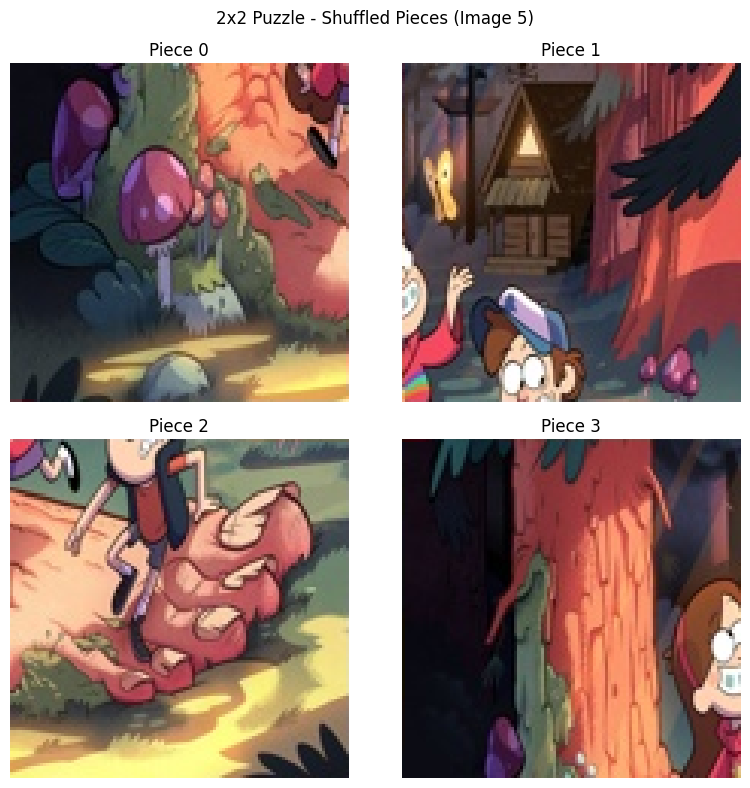

In [5]:
# Display shuffled pieces
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for idx, piece in enumerate(pieces_dict_2x2["original"]):
    row, col = idx // 2, idx % 2
    axes[row, col].imshow(piece)
    axes[row, col].set_title(f"Piece {idx}")
    axes[row, col].axis("off")
plt.suptitle("2x2 Puzzle - Shuffled Pieces (Image 5)")
plt.tight_layout()
plt.show()

### Intermediate Step: Edge Matching Analysis


In [6]:
# Compute and display top candidate matches
print("Computing candidate matches for 2x2 puzzle...\n")
matches_2x2 = compute_top_matches(pieces_dict_2x2, sim_calc, top_k=3)

orientation_names = ["Top", "Bottom", "Left", "Right"]
for orientation, matches in matches_2x2.items():
    print(f"\nBest matches for {orientation_names[orientation]} edge:")
    for i, (p1, p2, score) in enumerate(matches, 1):
        print(f"  {i}. Piece {p1} <-> Piece {p2}: Score = {score:.2f}")

Computing candidate matches for 2x2 puzzle...


Best matches for Top edge:
  1. Piece 2 <-> Piece 1: Score = 1659489.58
  2. Piece 0 <-> Piece 3: Score = 1865305.31
  3. Piece 1 <-> Piece 3: Score = 16784064.14

Best matches for Bottom edge:
  1. Piece 1 <-> Piece 2: Score = 1664233.20
  2. Piece 3 <-> Piece 0: Score = 1873317.33
  3. Piece 3 <-> Piece 1: Score = 16811932.15

Best matches for Left edge:
  1. Piece 2 <-> Piece 0: Score = 1460426.38
  2. Piece 1 <-> Piece 3: Score = 4548532.37
  3. Piece 3 <-> Piece 2: Score = 13711640.11

Best matches for Right edge:
  1. Piece 0 <-> Piece 2: Score = 1472666.51
  2. Piece 3 <-> Piece 1: Score = 4570491.84
  3. Piece 2 <-> Piece 3: Score = 13718775.92

Best matches for Top edge:
  1. Piece 2 <-> Piece 1: Score = 1659489.58
  2. Piece 0 <-> Piece 3: Score = 1865305.31
  3. Piece 1 <-> Piece 3: Score = 16784064.14

Best matches for Bottom edge:
  1. Piece 1 <-> Piece 2: Score = 1664233.20
  2. Piece 3 <-> Piece 0: Score = 1873317.33
  3. P

### Solve the Puzzle


In [7]:
# Solve using genetic algorithm
solution_2x2 = solve(
    pieces_dict_2x2,
    rows=2,
    cols=2,
    method="genetic",
    similarity=sim_calc,
    generations=50,
    population_size=50,
)

print(f"Solution: {solution_2x2}")
ground_truth = [0, 1, 2, 3]
accuracy = calculate_accuracy(solution_2x2, ground_truth)

Computing dissimilarities...
Initializing population...
Gen 0: fitness = 0.0001
Gen 10: fitness = 0.0001
Gen 20: fitness = 0.0001
Early stop at gen 21
Final fitness: 0.0001
Solution: [3, 1, 0, 2]
Initializing population...
Gen 0: fitness = 0.0001
Gen 10: fitness = 0.0001
Gen 20: fitness = 0.0001
Early stop at gen 21
Final fitness: 0.0001
Solution: [3, 1, 0, 2]


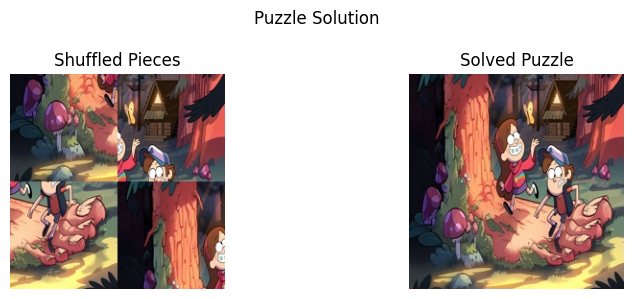

In [8]:
# Display final result
display_puzzle_comparison(
    pieces_dict_2x2["original"],
    solution_2x2,
    grid_size=2,
)

---

# Success Case 2: Image 40 (4x4 Puzzle)

Medium complexity puzzle with good texture variation.


In [9]:
# Preprocess puzzle and load it
puzzle_id_4x4 = 6
grid_size_4x4 = 4
size_name_4x4 = f"{grid_size_4x4}x{grid_size_4x4}"
output_dir_4x4 = Path(f"output/tiles_{size_name_4x4}")
input_path_4x4 = Path("data") / f"puzzle_{size_name_4x4}" / f"{puzzle_id_4x4}.jpg"
preprocess_puzzle(str(input_path_4x4), output_dir_4x4, puzzle_id_4x4, grid_size_4x4)

loader_4x4 = PieceLoader(str(output_dir_4x4), grid_size="4x4")
pieces_dict_4x4 = loader_4x4.load_all_types(puzzle_id_4x4)

print(f"Loaded puzzle {puzzle_id_4x4} (4x4)")
print(f"Number of pieces: {len(pieces_dict_4x4['original'])}")

✓ Preprocessed puzzle 6 (4x4) -> output/tiles_4x4
Loaded puzzle 6 (4x4)
Number of pieces: 16


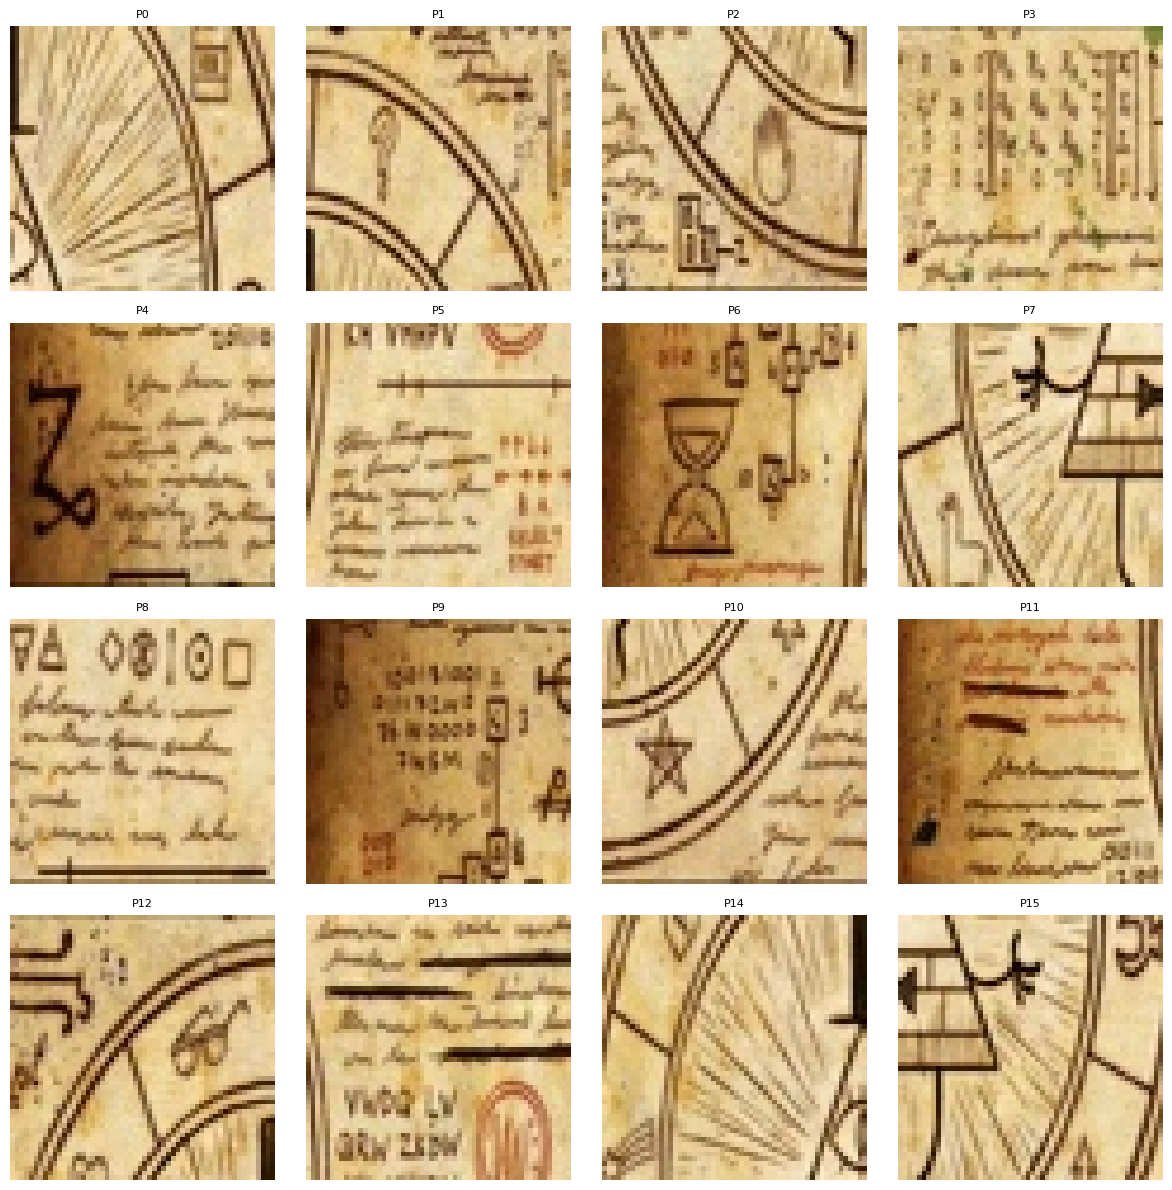

In [10]:
# Display shuffled pieces
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for idx, piece in enumerate(pieces_dict_4x4["original"]):
    row, col = idx // 4, idx % 4
    axes[row, col].imshow(piece)
    axes[row, col].set_title(f"P{idx}", fontsize=8)
    axes[row, col].axis("off")
plt.tight_layout()
plt.show()

### Intermediate Step: Candidate Matches Visualization


In [11]:
# Compute top matches for horizontal connections
matches_4x4 = compute_top_matches(pieces_dict_4x4, sim_calc, top_k=8)

print("Top 8 horizontal (right-edge) matches for 4x4 puzzle:\n")
for i, (p1, p2, score) in enumerate(matches_4x4[3][:8], 1):
    print(f"  {i}. Piece {p1:2d} <-> Piece {p2:2d}: Score = {score:.2f}")

Top 8 horizontal (right-edge) matches for 4x4 puzzle:

  1. Piece  7 <-> Piece 15: Score = 406404.76
  2. Piece  2 <-> Piece 10: Score = 793114.00
  3. Piece  9 <-> Piece 12: Score = 1112680.79
  4. Piece  8 <-> Piece  3: Score = 1297820.38
  5. Piece  1 <-> Piece  3: Score = 1369893.57
  6. Piece 12 <-> Piece  1: Score = 1630081.62
  7. Piece  5 <-> Piece  3: Score = 1895654.02
  8. Piece 10 <-> Piece  8: Score = 1919506.92


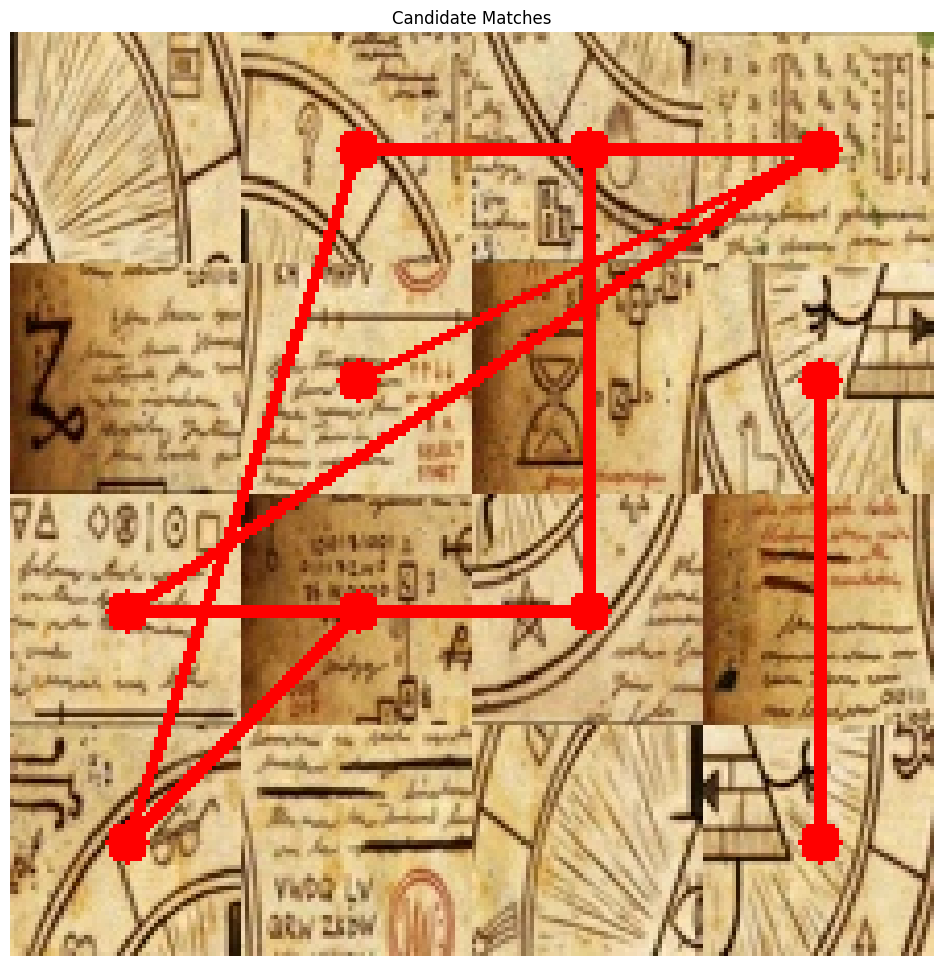

In [12]:
# Draw candidate match connections
draw_match_connections(
    pieces_dict_4x4["original"],
    matches_4x4[3][:8],  # Top 8 horizontal matches
    grid_size=4,
)

### Solve the Puzzle


In [13]:
# Solve using genetic algorithm
print("Solving 4x4 puzzle with genetic algorithm...")
solution_4x4 = solve(
    pieces_dict_4x4,
    rows=4,
    cols=4,
    method="genetic",
    similarity=sim_calc,
    generations=100,
    population_size=100,
)

Solving 4x4 puzzle with genetic algorithm...
Computing dissimilarities...
Initializing population...
Gen 0: fitness = 0.0000
Initializing population...
Gen 0: fitness = 0.0000
Gen 10: fitness = 0.0000
Gen 10: fitness = 0.0000
Gen 20: fitness = 0.0000
Early stop at gen 21
Final fitness: 0.0000
Gen 20: fitness = 0.0000
Early stop at gen 21
Final fitness: 0.0000


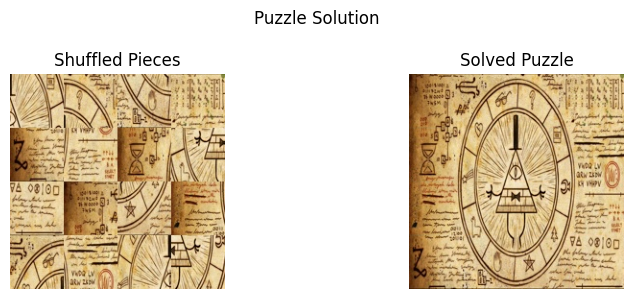

In [14]:
# Display final result
display_puzzle_comparison(
    pieces_dict_4x4["original"],
    solution_4x4,
    grid_size=4,
)

---

# Success Case 3: Image 88 (8x8 Puzzle)

Large puzzle demonstrating scalability of the system.


In [15]:
# Preprocess puzzle and load it
puzzle_id_8x8 = 57
grid_size_8x8 = 8
size_name_8x8 = f"{grid_size_8x8}x{grid_size_8x8}"
output_dir_8x8 = Path(f"output/tiles_{size_name_8x8}")
input_path_8x8 = Path("data") / f"puzzle_{size_name_8x8}" / f"{puzzle_id_8x8}.jpg"
preprocess_puzzle(str(input_path_8x8), output_dir_8x8, puzzle_id_8x8, grid_size_8x8)

loader_8x8 = PieceLoader(str(output_dir_8x8), grid_size="8x8")
pieces_dict_8x8 = loader_8x8.load_all_types(puzzle_id_8x8)

print(f"Loaded puzzle {puzzle_id_8x8} (8x8)")
print(f"Number of pieces: {len(pieces_dict_8x8['original'])}")

✓ Preprocessed puzzle 57 (8x8) -> output/tiles_8x8
Loaded puzzle 57 (8x8)
Number of pieces: 64


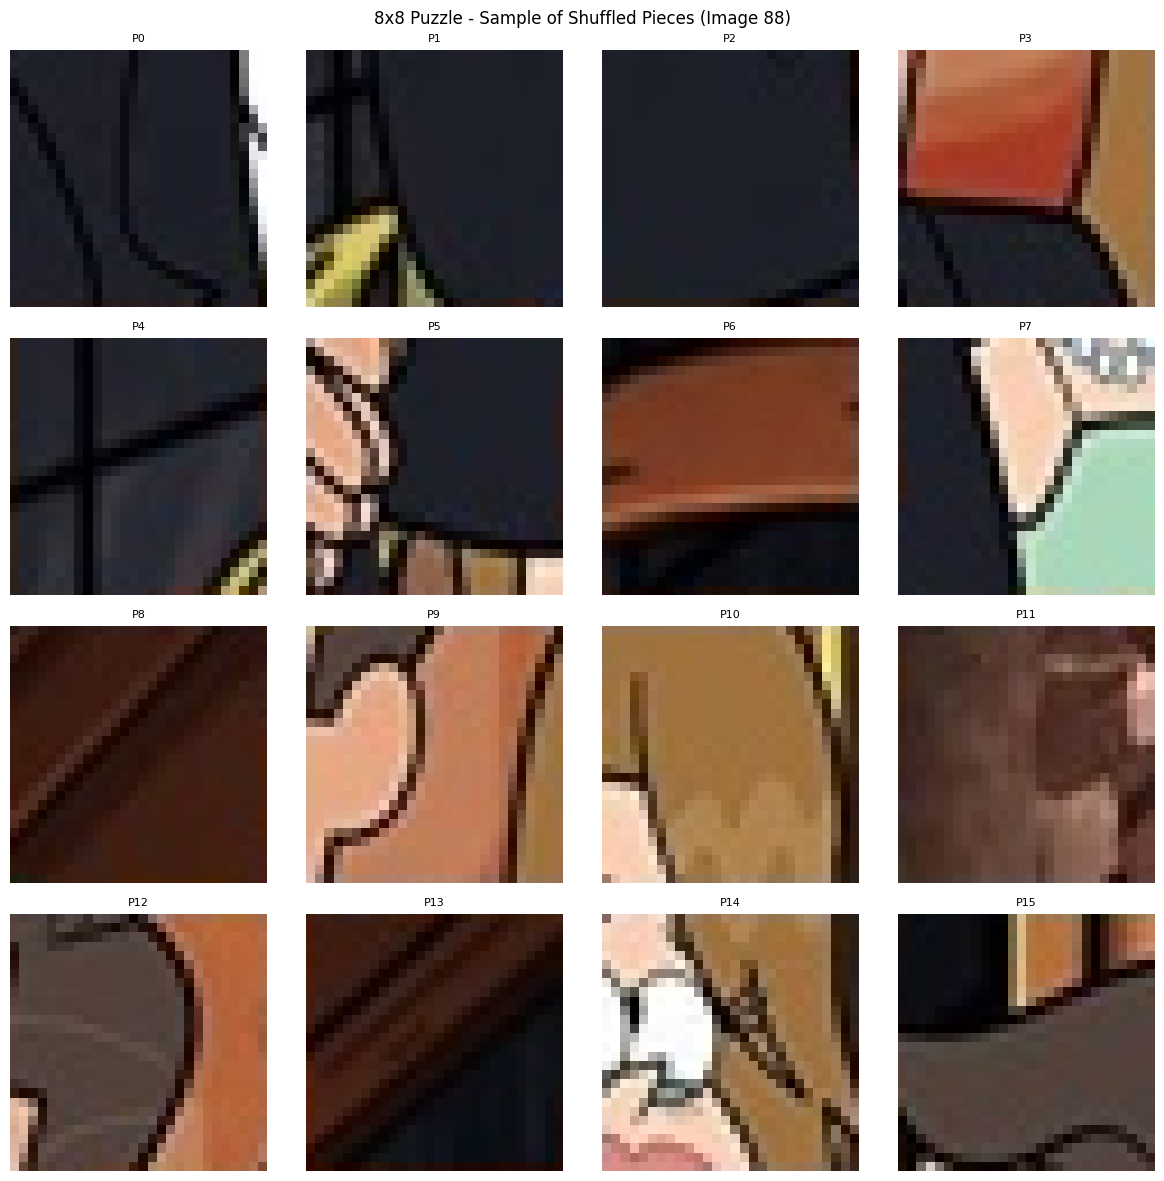

In [16]:
# Display subset of shuffled pieces
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for idx in range(16):
    row, col = idx // 4, idx % 4
    axes[row, col].imshow(pieces_dict_8x8["original"][idx])
    axes[row, col].set_title(f"P{idx}", fontsize=8)
    axes[row, col].axis("off")
plt.suptitle("8x8 Puzzle - Sample of Shuffled Pieces (Image 88)")
plt.tight_layout()
plt.show()

### Intermediate Step: Match Analysis for Large Puzzle


In [17]:
# Compute top matches
print("Computing candidate matches for 8x8 puzzle (this may take a moment)...\n")
matches_8x8 = compute_top_matches(pieces_dict_8x8, sim_calc, top_k=10)

print("Top 10 horizontal (right-edge) matches for 8x8 puzzle:\n")
for i, (p1, p2, score) in enumerate(matches_8x8[3][:10], 1):
    print(f"  {i:2d}. Piece {p1:2d} <-> Piece {p2:2d}: Score = {score:.2f}")

Computing candidate matches for 8x8 puzzle (this may take a moment)...

Top 10 horizontal (right-edge) matches for 8x8 puzzle:

   1. Piece 51 <-> Piece 28: Score = 925.37
   2. Piece  1 <-> Piece  2: Score = 1652.59
   3. Piece 51 <-> Piece 57: Score = 1823.12
   4. Piece 57 <-> Piece 28: Score = 1833.08
   5. Piece 22 <-> Piece 27: Score = 1936.89
   6. Piece 48 <-> Piece  2: Score = 2478.61
   7. Piece 19 <-> Piece 27: Score = 2820.10
   8. Piece  1 <-> Piece 33: Score = 3021.11
   9. Piece  1 <-> Piece  7: Score = 3322.69
  10. Piece 48 <-> Piece 33: Score = 4001.09
Top 10 horizontal (right-edge) matches for 8x8 puzzle:

   1. Piece 51 <-> Piece 28: Score = 925.37
   2. Piece  1 <-> Piece  2: Score = 1652.59
   3. Piece 51 <-> Piece 57: Score = 1823.12
   4. Piece 57 <-> Piece 28: Score = 1833.08
   5. Piece 22 <-> Piece 27: Score = 1936.89
   6. Piece 48 <-> Piece  2: Score = 2478.61
   7. Piece 19 <-> Piece 27: Score = 2820.10
   8. Piece  1 <-> Piece 33: Score = 3021.11
   9. Pi

### Solve the Puzzle


In [18]:
# Solve using genetic algorithm with more generations
solution_8x8 = solve(
    pieces_dict_8x8,
    rows=8,
    cols=8,
    method="genetic",
    similarity=sim_calc,
    generations=150,
    population_size=100,
)

Computing dissimilarities...
Initializing population...
Gen 0: fitness = 0.0000
Initializing population...
Gen 0: fitness = 0.0000
Gen 10: fitness = 0.0000
Gen 10: fitness = 0.0000
Gen 20: fitness = 0.0000
Gen 20: fitness = 0.0000
Gen 30: fitness = 0.0000
Gen 30: fitness = 0.0000
Gen 40: fitness = 0.0000
Gen 40: fitness = 0.0000
Gen 50: fitness = 0.0000
Gen 50: fitness = 0.0000
Gen 60: fitness = 0.0000
Gen 60: fitness = 0.0000
Gen 70: fitness = 0.0000
Gen 70: fitness = 0.0000
Gen 80: fitness = 0.0000
Gen 80: fitness = 0.0000
Gen 90: fitness = 0.0000
Gen 90: fitness = 0.0000
Gen 100: fitness = 0.0000
Gen 100: fitness = 0.0000
Gen 110: fitness = 0.0000
Gen 110: fitness = 0.0000
Gen 120: fitness = 0.0000
Gen 120: fitness = 0.0000
Gen 130: fitness = 0.0000
Gen 130: fitness = 0.0000
Gen 140: fitness = 0.0000
Gen 140: fitness = 0.0000
Early stop at gen 143
Final fitness: 0.0000
Early stop at gen 143
Final fitness: 0.0000


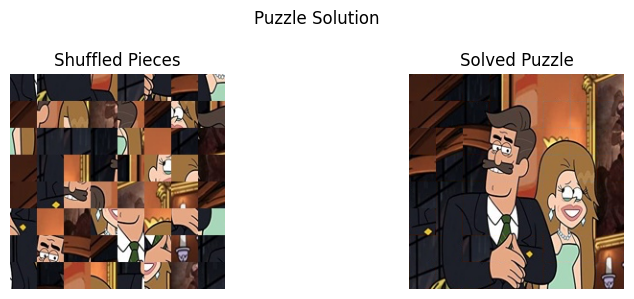

In [19]:
# Display final result
display_puzzle_comparison(
    pieces_dict_8x8["original"],
    solution_8x8,
    grid_size=8,
)

---

# Failure Case: Images 26

These small puzzles demonstrate how preprocessing and parameter tuning can affect results, particularly for images with low color variation.

## Normal Solve with Default Parameters

Using the default SimilarityCalculator settings.


✓ Preprocessed puzzle 26 (2x2) -> output/tiles_2x2
Loaded puzzle 26 (2x2)
Computing dissimilarities...
Initializing population...
Gen 0: fitness = 0.0002
Gen 10: fitness = 0.0002
Gen 20: fitness = 0.0002
Early stop at gen 21
Final fitness: 0.0002
Solution for image 26 (default): [2, 0, 3, 1]
Accuracy: 0.0%


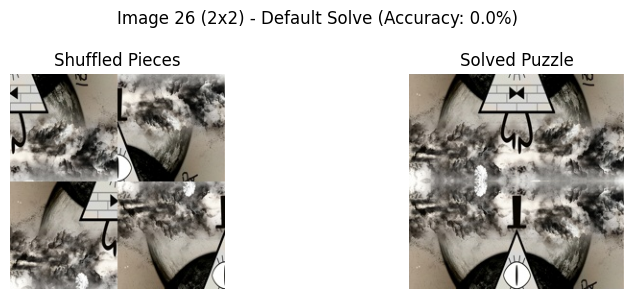

In [20]:
# Preprocess and solve image 26 (2x2) with default settings
puzzle_id_26 = 26
grid_size_26 = 2
size_name_26 = f"{grid_size_26}x{grid_size_26}"
output_dir_26 = Path(f"output/tiles_{size_name_26}")
input_path_26 = Path("data") / f"puzzle_{size_name_26}" / f"{puzzle_id_26}.jpg"
preprocess_puzzle(str(input_path_26), output_dir_26, puzzle_id_26, grid_size_26)

loader_26 = PieceLoader(str(output_dir_26), grid_size="2x2")
pieces_dict_26 = loader_26.load_all_types(puzzle_id_26)

print(f"Loaded puzzle {puzzle_id_26} (2x2)")

# Solve with default sim_calc
solution_26_default = solve(
    pieces_dict_26,
    rows=2,
    cols=2,
    method="genetic",
    similarity=sim_calc,
    generations=50,
    population_size=50,
)

print(f"Solution for image 26 (default): {solution_26_default}")
ground_truth_26 = [0, 1, 2, 3]
accuracy_26_default = calculate_accuracy(solution_26_default, ground_truth_26)
print(f"Accuracy: {accuracy_26_default:.1f}%")

display_puzzle_comparison(
    pieces_dict_26["original"],
    solution_26_default,
    grid_size=2,
    title=f"Image 26 (2x2) - Default Solve (Accuracy: {accuracy_26_default:.1f}%)",
)

## Solve with Tuned Parameters

Using adjusted SimilarityCalculator settings to match the special config (higher black_threshold, adjusted weights).


In [21]:
# Initialize tuned similarity calculator
sim_calc_tuned = SimilarityCalculator(
    weight_color=0.0,  # From special config
    weight_edge=2.0,  # Adjusted
    weight_contour=1.5,  # Adjusted
    color_depth=5,  # From special config
    edge_depth=2,  # From special config
    black_threshold=50,  # Key difference: higher threshold
)

print("✓ Tuned similarity calculator initialized (black_threshold=50)")

✓ Tuned similarity calculator initialized (black_threshold=50)


Computing dissimilarities...
Initializing population...
Gen 0: fitness = 0.0009
Gen 10: fitness = 0.0009
Gen 20: fitness = 0.0009
Early stop at gen 21
Final fitness: 0.0009
Initializing population...
Gen 0: fitness = 0.0009
Gen 10: fitness = 0.0009
Gen 20: fitness = 0.0009
Early stop at gen 21
Final fitness: 0.0009


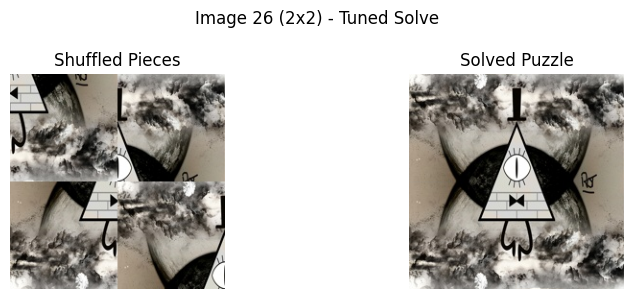

In [22]:
# Solve image 26 with tuned parameters
solution_26_tuned = solve(
    pieces_dict_26,
    rows=2,
    cols=2,
    method="genetic",
    similarity=sim_calc_tuned,
    generations=50,
    population_size=50,
)

display_puzzle_comparison(
    pieces_dict_26["original"],
    solution_26_tuned,
    grid_size=2,
    title=f"Image 26 (2x2) - Tuned Solve",
)

## Analysis: Why Tuned Parameters Work Better

The key difference is the **black_threshold** setting:

- **Default**: `black_threshold=20` - Filters out more dark/black pixels, which can remove important edge information in low-contrast images.
- **Tuned**: `black_threshold=50` - Includes more dark areas in similarity calculations, preserving details that help distinguish pieces in uniform.
